# 02 — Model training (leakage-safe)

Loads processed **`X`** and **`y`** from disk (no hidden kernel state), performs train/test split **before** feature selection, selects CpGs using **training** labels only, fits a scaler on the training set, trains a single **ElasticNetCV**, evaluates on the hold-out set, and writes predictions and model artifacts.

**Prerequisite:** run `01_data_loading.ipynb` first.

## Dependencies

In [1]:
%pip install -q pandas pyarrow scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


## Paths

In [2]:
from pathlib import Path

PROJECT_DIR = Path("..").resolve()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_TOP_CPGS = 5000

## Load processed `X` and `y`

In [3]:
import pandas as pd

x_path = PROCESSED_DIR / "X.pkl.gz"
y_path = PROCESSED_DIR / "y.csv"
if not x_path.is_file() or not y_path.is_file():
    raise FileNotFoundError(
        "Run 01_data_loading.ipynb first. Expected:\n" + str(x_path) + "\n" + str(y_path)
    )

X = pd.read_pickle(x_path, compression="gzip")
y_frame = pd.read_csv(y_path, index_col=0)
y = y_frame["age"].astype(float)

common = X.index.intersection(y.index).sort_values()
X = X.loc[common].astype("float32")
y = y.loc[common]
assert X.shape[0] == y.shape[0]
print("Loaded X:", X.shape, "y:", y.shape)

Loaded X: (656, 473034) y: (656,)


## Train / test split (before any feature selection)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (524, 473034) Test: (132, 473034)


## Leakage-safe CpG selection (training set only)

Rank probes by absolute Pearson correlation with age on **training** samples only; take the top `N_TOP_CPGS`.

In [5]:
train_corr = X_train.corrwith(y_train)
selected_cpgs = train_corr.abs().sort_values(ascending=False).head(N_TOP_CPGS).index

X_train_sel = X_train[selected_cpgs]
X_test_sel = X_test[selected_cpgs]

## Standardize using training statistics only

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train_sel)
X_test_z = scaler.transform(X_test_sel)

## Elastic Net CV (single canonical model)

In [7]:
import numpy as np
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = ElasticNetCV(
    l1_ratio=[0.7, 0.8, 0.9, 0.95, 1.0],
    alphas=np.logspace(-3, 1, 30),
    cv=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_iter=30000,
)
model.fit(X_train_z, y_train)

y_pred = model.predict(X_test_z)
mae = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2 = r2_score(y_test, y_pred)
corr = float(np.corrcoef(y_test, y_pred)[0, 1])

print("Best alpha:", model.alpha_, "l1_ratio:", model.l1_ratio_)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Correlation:", corr)

Best alpha: 0.001 l1_ratio: 0.7
MAE: 3.703633684100527
RMSE: 4.934051858996752
R2: 0.8930417228637542
Correlation: 0.9451549784643478


## Non-zero coefficients → `top_cpgs.csv`

In [8]:
coef = pd.Series(model.coef_, index=selected_cpgs)
nz = coef[coef != 0]
top_cpgs_df = nz.rename("coefficient").reset_index().rename(columns={"index": "cpg"})
top_cpgs_df["abs_coef"] = top_cpgs_df["coefficient"].abs()
top_cpgs_df = top_cpgs_df.sort_values("abs_coef", ascending=False)

## Predictions (test set)

In [9]:
predictions_df = pd.DataFrame(
    {"real_age": y_test, "predicted_age": y_pred},
    index=y_test.index,
)
predictions_df["age_acceleration"] = (
    predictions_df["predicted_age"] - predictions_df["real_age"]
)
display(predictions_df.head())

,real_age,predicted_age,age_acceleration
X2001,49.0,54.051479,5.051479
X2084,56.0,53.857880,-2.142120
X1090,85.0,84.687630,-0.312370
X9022,78.0,79.429123,1.429123
X6093,47.0,52.946316,5.946316


## Plots

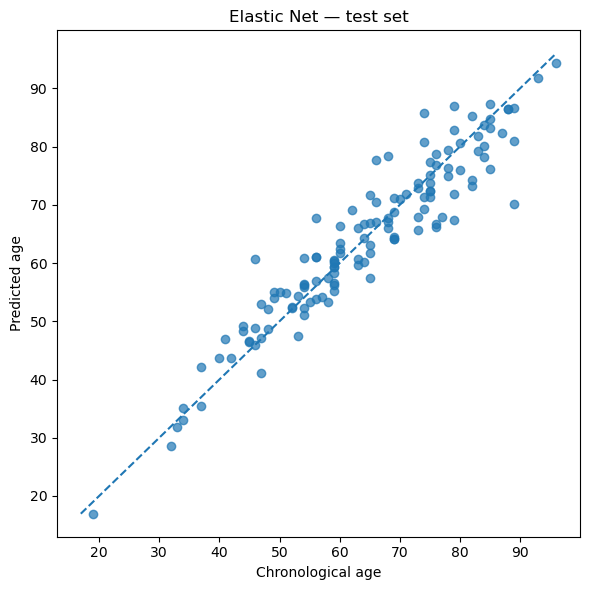

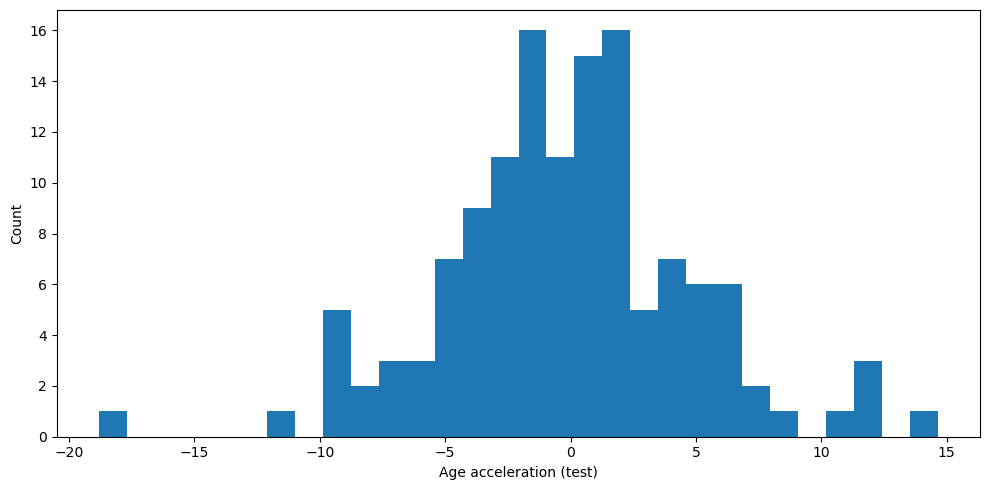

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.7)
ax.set_xlabel("Chronological age")
ax.set_ylabel("Predicted age")
ax.set_title("Elastic Net — test set")
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], ls="--")
fig.tight_layout()
scatter_path = RESULTS_DIR / "age_prediction_scatter.png"
fig.savefig(scatter_path, dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.hist(predictions_df["age_acceleration"], bins=30)
ax2.set_xlabel("Age acceleration (test)")
ax2.set_ylabel("Count")
fig2.tight_layout()
hist_path = RESULTS_DIR / "age_acceleration_hist.png"
fig2.savefig(hist_path, dpi=150)
plt.show()

## Repeated split stability evaluation

This section runs several **independent, leakage-safe** train/test splits with fixed seeds. Each run repeats the full pipeline—split → train-only correlation filtering → `StandardScaler` fit on training rows only → `ElasticNetCV` on the training set → evaluation on the held-out test set—so **test labels never influence feature selection or scaling**.

The goal is to summarize **robustness** of predictive accuracy (MAE, RMSE, R², Pearson correlation) and of **which CpGs receive non-zero coefficients**, including probe **`cg16867657`**, across random partitions. Large swings across seeds suggest sensitivity to sample composition; stable metrics and recurring probes suggest more consistent clock behavior.

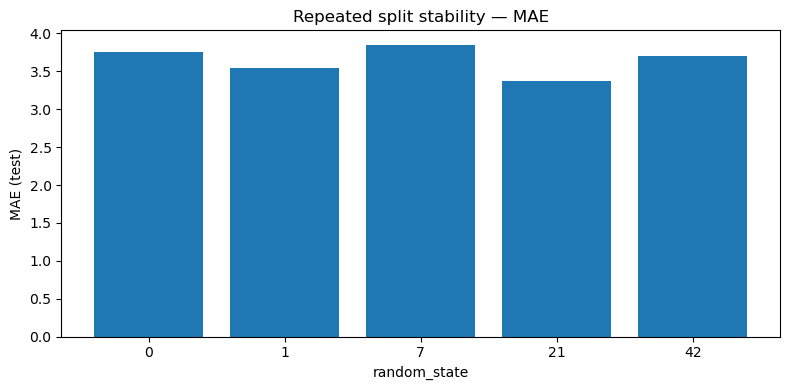

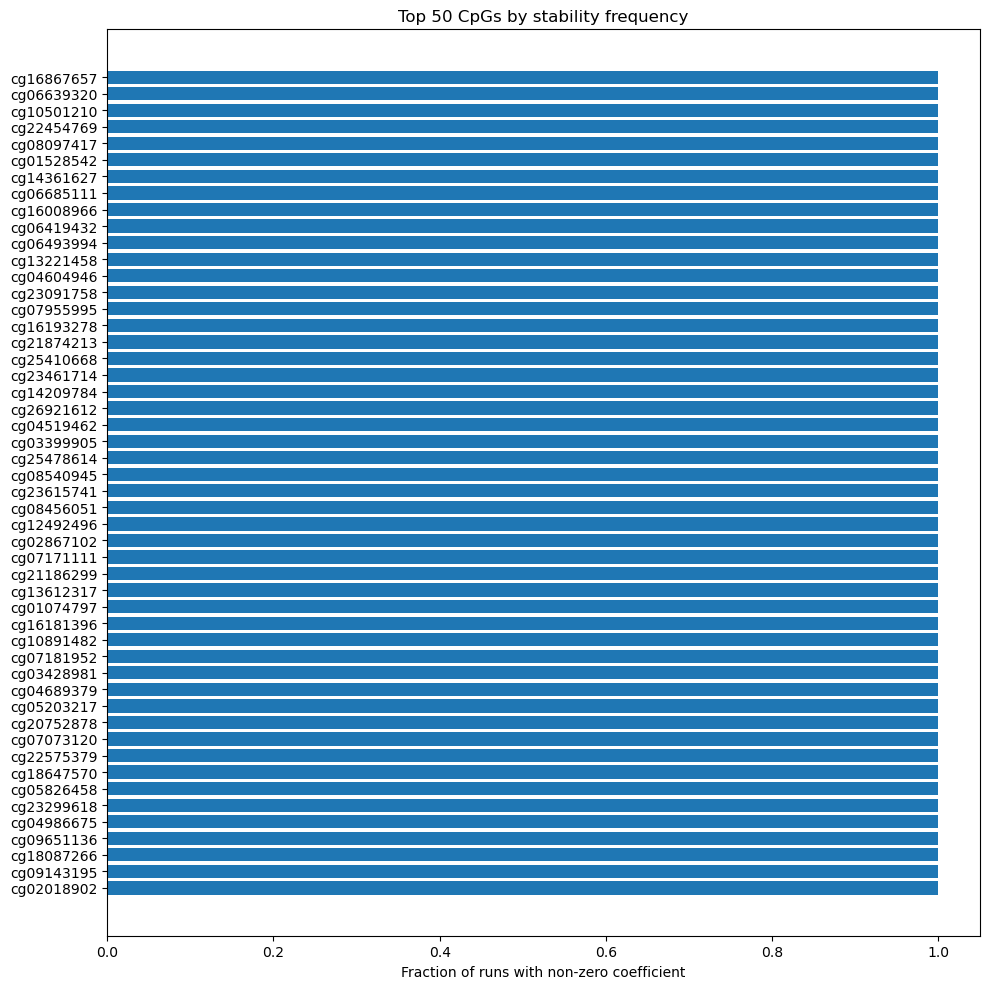

,seed,MAE,RMSE,R2,pearson_r,n_nonzero_cpgs,cg16867657_selected,cg16867657_rank_by_abs_coef
0,0,3.749510,5.300093,0.870084,0.933341,311,True,1
1,1,3.540025,4.494616,0.902350,0.949961,574,True,1
2,7,3.849241,5.023403,0.902328,0.950148,411,True,1
3,21,3.374397,4.495219,0.896432,0.949586,432,True,1
4,42,3.703634,4.934052,0.893042,0.945155,691,True,1


In [11]:
from collections import Counter

STABILITY_SEEDS = [0, 1, 7, 21, 42]
TARGET_CPG = "cg16867657"

stability_rows = []
nonzero_counter = Counter()

for seed in STABILITY_SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    tr_corr = X_tr.corrwith(y_tr)
    sel_seed = tr_corr.abs().sort_values(ascending=False).head(N_TOP_CPGS).index

    scaler_s = StandardScaler()
    X_tr_z = scaler_s.fit_transform(X_tr[sel_seed])
    X_te_z = scaler_s.transform(X_te[sel_seed])

    model_s = ElasticNetCV(
        l1_ratio=[0.7, 0.8, 0.9, 0.95, 1.0],
        alphas=np.logspace(-3, 1, 30),
        cv=10,
        random_state=seed,
        n_jobs=-1,
        max_iter=30000,
    )
    model_s.fit(X_tr_z, y_tr)
    y_hat = model_s.predict(X_te_z)

    mae_s = mean_absolute_error(y_te, y_hat)
    rmse_s = float(np.sqrt(mean_squared_error(y_te, y_hat)))
    r2_s = r2_score(y_te, y_hat)
    pearson_s = float(np.corrcoef(y_te, y_hat)[0, 1])

    coef_s = pd.Series(model_s.coef_, index=sel_seed)
    nz_mask = coef_s != 0
    n_nz = int(nz_mask.sum())
    for cpg in coef_s[nz_mask].index:
        nonzero_counter[str(cpg)] += 1

    if TARGET_CPG in coef_s.index and coef_s.loc[TARGET_CPG] != 0:
        order = coef_s[nz_mask].abs().sort_values(ascending=False).index
        rank_map = {c: i + 1 for i, c in enumerate(order)}
        cg_rank = rank_map.get(TARGET_CPG, np.nan)
        cg_sel = True
    else:
        cg_sel = False
        cg_rank = np.nan

    stability_rows.append(
        {
            "seed": seed,
            "MAE": mae_s,
            "RMSE": rmse_s,
            "R2": r2_s,
            "pearson_r": pearson_s,
            "n_nonzero_cpgs": n_nz,
            "cg16867657_selected": cg_sel,
            "cg16867657_rank_by_abs_coef": cg_rank,
        }
    )

    del X_tr, X_te, X_tr_z, X_te_z, model_s, coef_s

repeated_split_metrics_path = RESULTS_DIR / "repeated_split_metrics.csv"
pd.DataFrame(stability_rows).to_csv(repeated_split_metrics_path, index=False)

freq_rows = [
    {
        "cpg": cpg,
        "n_runs_nonzero": cnt,
        "frequency": cnt / len(STABILITY_SEEDS),
    }
    for cpg, cnt in nonzero_counter.most_common()
]
cpg_stability_path = RESULTS_DIR / "cpg_stability_frequency.csv"
pd.DataFrame(freq_rows).to_csv(cpg_stability_path, index=False)

rep_df = pd.DataFrame(stability_rows)
fig_mae, ax_mae = plt.subplots(figsize=(8, 4))
ax_mae.bar(rep_df["seed"].astype(str), rep_df["MAE"])
ax_mae.set_xlabel("random_state")
ax_mae.set_ylabel("MAE (test)")
ax_mae.set_title("Repeated split stability — MAE")
fig_mae.tight_layout()
repeated_mae_path = RESULTS_DIR / "repeated_split_mae.png"
fig_mae.savefig(repeated_mae_path, dpi=150)
plt.show()

top50_freq = freq_rows[:50]
labels = [r["cpg"] for r in top50_freq][::-1]
vals = [r["frequency"] for r in top50_freq][::-1]
fig_top, ax_top = plt.subplots(figsize=(10, 10))
ax_top.barh(labels, vals)
ax_top.set_xlabel("Fraction of runs with non-zero coefficient")
ax_top.set_title("Top 50 CpGs by stability frequency")
fig_top.tight_layout()
cpg_stability_plot_path = RESULTS_DIR / "cpg_stability_top50.png"
fig_top.savefig(cpg_stability_plot_path, dpi=150)
plt.show()

display(rep_df)

## Save results

In [12]:
predictions_path = RESULTS_DIR / "predictions.csv"
metrics_path = RESULTS_DIR / "model_metrics.csv"
top_path = RESULTS_DIR / "top_cpgs.csv"

predictions_df.to_csv(predictions_path)

metrics_df = pd.DataFrame(
    [
        {
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "Correlation": corr,
            "alpha": float(model.alpha_),
            "l1_ratio": float(model.l1_ratio_),
            "n_nonzero_coef": int((model.coef_ != 0).sum()),
            "n_top_candidates": int(N_TOP_CPGS),
            "random_state": RANDOM_STATE,
        }
    ]
)
metrics_df.to_csv(metrics_path, index=False)
top_cpgs_df.to_csv(top_path, index=False)

exports = [
    predictions_path,
    metrics_path,
    top_path,
    scatter_path,
    hist_path,
    repeated_split_metrics_path,
    cpg_stability_path,
    repeated_mae_path,
    cpg_stability_plot_path,
]
print("Exported:")
for p in exports:
    print(" -", p.resolve())

Exported:
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\predictions.csv
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\model_metrics.csv
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\top_cpgs.csv
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\age_prediction_scatter.png
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\age_acceleration_hist.png
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\repeated_split_metrics.csv
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\cpg_stability_frequency.csv
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\repeated_split_mae.png
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\cpg_stability_top50.png


## Permutation sanity test

If the pipeline is **leakage-safe**, assigning **randomly permuted** outcome labels should destroy predictable signal in held-out data: test-set MAE/RMSE should rise toward uninformative baselines and **R²** and **Pearson correlation** between predictions and labels should **collapse toward zero** (aside from finite-sample noise). This contrasts with the **real-label** model trained earlier in the notebook.

In [13]:
np.random.seed(42)
y_perm = pd.Series(np.random.permutation(y.values), index=y.index)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_perm, test_size=0.2, random_state=42
)

train_corr_p = X_train_p.corrwith(y_train_p)
selected_cpgs_p = train_corr_p.abs().sort_values(ascending=False).head(N_TOP_CPGS).index

scaler_p = StandardScaler()
X_train_sel_p = scaler_p.fit_transform(X_train_p[selected_cpgs_p])
X_test_sel_p = scaler_p.transform(X_test_p[selected_cpgs_p])

model_perm = ElasticNetCV(
    l1_ratio=[0.7, 0.8, 0.9, 0.95, 1.0],
    alphas=np.logspace(-3, 1, 30),
    cv=10,
    random_state=42,
    n_jobs=-1,
    max_iter=30000,
)
model_perm.fit(X_train_sel_p, y_train_p)
y_pred_perm = model_perm.predict(X_test_sel_p)

mae_perm = mean_absolute_error(y_test_p, y_pred_perm)
rmse_perm = float(np.sqrt(mean_squared_error(y_test_p, y_pred_perm)))
r2_perm = r2_score(y_test_p, y_pred_perm)
pearson_perm = float(np.corrcoef(y_test_p, y_pred_perm)[0, 1])

comparison_perm = pd.DataFrame(
    [
        {
            "scenario": "real_labels",
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "pearson_r": corr,
        },
        {
            "scenario": "shuffled_labels",
            "MAE": mae_perm,
            "RMSE": rmse_perm,
            "R2": r2_perm,
            "pearson_r": pearson_perm,
        },
    ]
)

permutation_test_path = RESULTS_DIR / "permutation_test_metrics.csv"
comparison_perm.to_csv(permutation_test_path, index=False)
display(comparison_perm)
print("Saved:", permutation_test_path.resolve())

,scenario,MAE,RMSE,R2,pearson_r
0,real_labels,3.703634,4.934052,0.893042,0.945155
1,shuffled_labels,14.050546,17.503167,-0.240287,-0.099984


Saved: C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\permutation_test_metrics.csv
